# MMER-XGBoost hyperparameter search

This notebook tunes the XGBoost fixed-effects component of MMER using Optuna's TPE sampler. Each trial is evaluated by five-fold within-participant temporal validation with a six-hour embargo, maximizing uniform-average multivariate R² over pooled out-of-fold predictions. Standardized meals are excluded from model fitting.

## Notebook flow

1. Load and filter the prepared meal data and participant metadata using the search-specific eligibility rules.
2. Define the design matrices and temporally blocked validation folds.
3. Run or resume the Optuna study, evaluating each trial across parallel validation folds.
4. Inspect the best parameters and plot optimization history and parameter trajectories.

## Outputs

No CSV files are exported by the active code cells. `optuna_gridsearch.csv` appears only in an inactive raw-cell example.

- `code/hyperparameter_search/mmer_optuna.db`: persistent trials, parameters, and validation scores for the `mmer_xgb_parallel_folds` study.
- `code/hyperparameter_search/Figures/optuna_optimization_history.svg`: trial performance and best-so-far performance.
- `code/hyperparameter_search/Figures/optuna_params_over_trials.svg`: parameter values and performance across trials.

## 1. Setup and analysis sample

Resolve data, study-database, and figure paths, then prepare participant metadata and filter the meal-level search sample.

In [1]:
from pathlib import Path
import sys

# Find the project when launched from its root, code/, or a notebook subfolder.
for PROJECT_ROOT in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    CODE_DIR = PROJECT_ROOT / "code"
    if (CODE_DIR / "data_paths.py").is_file():
        break
else:
    raise FileNotFoundError("Open this notebook from within the project directory.")

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

# Shared defaults; override individual paths here if needed.
from data_paths import DATA_DIR, METADATA_PATH, MEAL_DATA_PATH, CGM_METRICS_PATH

SEARCH_DIR = CODE_DIR / "hyperparameter_search"
OPTUNA_STORAGE = f"sqlite:///{(SEARCH_DIR / 'mmer_optuna.db').as_posix()}"
FIGURES_DIR = SEARCH_DIR / "Figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# import libraries and data
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
# preprocess metadata
meta_data = pd.read_csv(METADATA_PATH)
meta_data.rename(columns={'subject_app_key':'subject_key'}, inplace=True)

if 'id' in meta_data.columns:
    id_to_subjectKey = dict(zip(meta_data['id'], meta_data['subject_key']))
    meta_data.rename(columns={'id':'fay-id'}, inplace=True)
else:
    id_to_subjectKey = dict(zip(meta_data['fay-id'], meta_data['subject_key']))

# Age is supplied by the prepared Data/metadata.csv table.

def compute_bmi(row) : 
    bmi = row["weight"] / (row["height"]**2)
    return bmi

meta_data["bmi"] = meta_data.apply(lambda row: row["weight"] / ((row["height"]/100)**2), axis=1)
meta_data["WaistHipRatio"] =meta_data["waist"] / meta_data["hip"]
meta_data["WaistHeightRatio"] =meta_data["waist"] / meta_data["height"]

In [3]:
df_food = pd.read_csv(MEAL_DATA_PATH, index_col=0)

df_food["closest_end_time"] = pd.to_datetime(df_food["closest_end_time"])
df_food["minutes_of_the_day"] = df_food["closest_end_time"].dt.hour * 60 + df_food["closest_end_time"].dt.minute
df_food["hours_numeric"] = df_food["closest_end_time"].dt.hour + df_food["closest_end_time"].dt.minute /60
df_food['weekday_index'] = df_food['closest_end_time'].dt.weekday 

### add demographic covariates
covariates = ["age", "bmi", "gender", "waist", "weight", "hip", "height", "WaistHipRatio", "WaistHeightRatio"]
df_food = pd.merge(df_food, meta_data[covariates + ["subject_key"]], on="subject_key", how="inner")
df_food['gender'] = df_food['gender'].map({'female': 0, 'male': 1})


In [4]:
df_food['time_since_last_meal'] = df_food['time_since_last_meal'].where(df_food['time_since_last_meal'] <= 24, np.nan)
df_food["time_since_last_meal"].describe()

df_food["time_since_last_meal"] = df_food["time_since_last_meal"].where(
    df_food["time_since_last_meal"] <= 24
)
df_food["time_to_next_meal"] = df_food["time_to_next_meal"].where(
    df_food["time_to_next_meal"] <= 24
)

In [5]:
df_food["estimated_net_carb_eaten"] = (df_food["carb_eaten"] - df_food["fiber_eaten"]).clip(lower=0)
df_food["estimated_sugar_fraction"] = (df_food["sugar_eaten"] / (df_food["carb_eaten"] + 1)).clip(lower=0)

In [6]:
#### remove 0-lengths iAUC : 
import ast
df_food = df_food[~df_food["ppgr_array"].isna()]

# remove ppgr arrays with equal values (cgm measurement issue)
# First, convert string representation to actual list if needed
df_food['ppgr_array_ast'] = df_food['ppgr_array'].apply(ast.literal_eval)

# Identify rows where all values are equal
df_food['all_equal'] = df_food['ppgr_array_ast'].apply(lambda x: len(set(x)) == 1)

df_food = df_food[~df_food["all_equal"]]
#df_plot[df_plot['all_equal']]["subject_key"].value_counts()
print(df_food.shape)

(98891, 132)


In [7]:
#### we remove participants with less tham 20 meals 
df_food["eaten_at"] = pd.to_datetime(df_food["eaten_at"])
df_food["eaten_date"] = df_food["eaten_at"].dt.date
data_summary = df_food.groupby("subject_key")["eaten_at"].agg(
    data_coverage=lambda x: x.max() - x.min(),
    count="size"
).reset_index()

participants_to_remove = data_summary[data_summary["count"]<20]["subject_key"].values

df_food= df_food[~df_food["subject_key"].isin(participants_to_remove)].reset_index(drop=True)

df_food = df_food[
    df_food.groupby('subject_key')['eaten_date'].transform('nunique').ge(7) # &
    #(data.groupby('subject_key')['eaten_date'].rank(method='dense') <= 30)
]
df_food = df_food.reset_index(drop=True)

print("everyday meal size:",df_food.shape)

print("Participants:",len(df_food["subject_key"].unique()))

everyday meal size: (98694, 133)
Participants: 992


In [8]:
# Clip negative values from all food columns 
positive_cols = ["carb_eaten", "fat_eaten", "protein_eaten", "fiber_eaten",
                 "eaten_quantity_in_gram", "energy_kcal_eaten",
                 "dairy_products_meat_fish_eggs_tofu", "vegetables_fruits",
                 "sweets_salty_snacks_alcohol", "non_alcoholic_beverages",
                 "grains_potatoes_pulses", "oils_fats_nuts",
                 'alcohol_eaten','beta_carotene_eaten','calcium_eaten','cholesterol_eaten',
                               'fatty_acids_monounsaturated_eaten','fatty_acids_polyunsaturated_eaten',
                               'fatty_acids_saturated_eaten','folate_eaten','iron_eaten','magnesium_eaten',
                               'niacin_eaten','pantothenic_acid_eaten','phosphorus_eaten','potassium_eaten',
                               'salt_eaten','sodium_eaten','sugar_eaten','vitamin_b1_eaten',
                               'vitamin_b12_eaten','vitamin_b2_eaten','vitamin_b6_eaten','vitamin_c_eaten','vitamin_d_eaten',
                                'zinc_eaten',
                 "prev_1hr_carb_eaten", "prev_2hr_carb_eaten", "prev_3hr_carb_eaten", "prev_6hr_carb_eaten",
                              "prev_1hr_fat_eaten", "prev_2hr_fat_eaten", "prev_3hr_fat_eaten", "prev_6hr_fat_eaten",
                              "prev_1hr_protein_eaten", "prev_2hr_protein_eaten", "prev_3hr_protein_eaten", "prev_6hr_protein_eaten",
                              "prev_1hr_fiber_eaten", "prev_2hr_fiber_eaten", "prev_3hr_fiber_eaten", "prev_6hr_fiber_eaten",
                              "prev_1hr_energy_kcal_eaten", "prev_2hr_energy_kcal_eaten", "prev_3hr_energy_kcal_eaten", "prev_6hr_energy_kcal_eaten"
                ]

df_food[positive_cols] = df_food[positive_cols].clip(lower=0)

df_food = df_food[df_food["energy_kcal_eaten"]<2000]

In [9]:
import ast
df_food = df_food[~df_food["ppgr_array"].isna()]

# remove ppgr arrays with equal values (cgm measurement issue)
# First, convert string representation to actual list if needed
df_food['ppgr_array_ast'] = df_food['ppgr_array'].apply(ast.literal_eval)

# Identify rows where all values are equal
df_food['all_equal'] = df_food['ppgr_array_ast'].apply(lambda x: len(set(x)) == 1)

df_food = df_food[~df_food["all_equal"]]
#df_plot[df_plot['all_equal']]["subject_key"].value_counts()


df_food = df_food.copy()

positive_covariates = ["carb_eaten", "fat_eaten", "protein_eaten", "fiber_eaten"]
df_food[positive_covariates] = df_food[positive_covariates].clip(lower=0)

####### last filtering steps
df_food = df_food[
    ((df_food['time_to_next_meal'] >= 2) | (df_food['time_to_next_meal'].isna()))
].copy()

df_food = df_food.reset_index(drop=True)

groups = df_food["subject_key"]#.astype('category').cat.codes.values

print(df_food.shape)

(54987, 133)


In [10]:
df_food = df_food[df_food["energy_kcal_eaten"]<2000]
data = df_food.reset_index(drop=True).copy()
print("N:", data["subject_key"].nunique())
print("data shape:", data.shape)

N: 992
data shape: (54987, 133)


## 2. Design matrices and temporal validation

Define the search-specific design-matrix builder and participant-level temporal splitter.

In [11]:
def to_32bit(x):
    arr = np.asarray(x)

    if np.issubdtype(arr.dtype, np.floating):
        return arr.astype(np.float32, copy=False)
    if np.issubdtype(arr.dtype, np.integer):
        return arr.astype(np.int32, copy=False)

    return x


def build_design_mats(data, train_idx=None, val_idx=None, target_outcome=None,
                      apply_mundlak=True,
                      use_interactions=[False],
                      population_z_scoring_features=True,
                      remove_features=None,
                      remove_std_meals_from_training=False,
                      random_slopes=None,
                      population_z_scoring_outcome=False,
                      full_train=False,
                     ):
    """
    Build design matrices for mixed-effects modeling.

    Parameters
    ----------
    data : pd.DataFrame
    train_idx, val_idx : array-like
    target_outcome : str
    apply_mundlak : bool
        If True: use within-person deviations + add subject means as fixed effects.
        If False: use raw intakes.
    use_interactions : list of str
        e.g., ['cho_fat'] -> interaction between carb and fat.
    population_z_scoring_features : bool
        If True: apply (X - mu) / sigma using training-set stats.
    remove_features : list of str or None
        Feature groups to drop. Valid groups:
        'nutritional', 'food_group', 'past_glucose', 'baseline_glucose',
        'past_food', 'context', 'demographics'.
    remove_std_meals_from_training : bool
    random_slopes : list of str or None
        Variables to use as random slopes in Z. Default: macros.

    Returns
    -------
    X_train, X_val, Z_train, Z_val, y_train, y_val,
    clusters_train, clusters_val, cluster_mapping, info
    """
    macros = ["carb_eaten", "fat_eaten", "protein_eaten", "fiber_eaten"]

    # Feature groups available for model comparisons.
    FEATURE_GROUPS = {
        # --- meal-level groups (go into X_macros, get centered if mundlak) ---
        "nutritional": [
            "energy_kcal_eaten", "eaten_quantity_in_gram", "estimated_net_carb_eaten","estimated_sugar_fraction",
            'alcohol_eaten', 'beta_carotene_eaten', 'calcium_eaten', 'cholesterol_eaten',
            'fatty_acids_monounsaturated_eaten', 'fatty_acids_polyunsaturated_eaten',
            'fatty_acids_saturated_eaten', 'folate_eaten', 'iron_eaten', 'magnesium_eaten',
            'niacin_eaten', 'pantothenic_acid_eaten', 'phosphorus_eaten', 'potassium_eaten',
            'salt_eaten', 'sodium_eaten', 'sugar_eaten', 'vitamin_b1_eaten',
            'vitamin_b12_eaten', 'vitamin_b2_eaten', 'vitamin_b6_eaten', 'vitamin_c_eaten',
            'vitamin_d_eaten', 'zinc_eaten',
        ],
        "food_group": [
            'grains_potatoes_pulses', 'sweets_salty_snacks_alcohol',
            'non_alcoholic_beverages', 'dairy_products_meat_fish_eggs_tofu',
            'vegetables_fruits', 'oils_fats_nuts',
        ],
        "baseline_glucose": [
            "premeal_glucose",
        ],
        "past_glucose": [
            "trend_glu_1", "trend_glu_2", "trend_glu_4", "trend_glu_6",
        ],
        "past_food": [
            "prev_1hr_carb_eaten", "prev_2hr_carb_eaten", "prev_3hr_carb_eaten", "prev_6hr_carb_eaten",
            "prev_1hr_fat_eaten", "prev_2hr_fat_eaten", "prev_3hr_fat_eaten", "prev_6hr_fat_eaten",
            "prev_1hr_protein_eaten", "prev_2hr_protein_eaten", "prev_3hr_protein_eaten", "prev_6hr_protein_eaten",
            "prev_1hr_fiber_eaten", "prev_2hr_fiber_eaten", "prev_3hr_fiber_eaten", "prev_6hr_fiber_eaten",
            "prev_1hr_energy_kcal_eaten", "prev_2hr_energy_kcal_eaten",
            "prev_3hr_energy_kcal_eaten", "prev_6hr_energy_kcal_eaten",
        ],
        # --- covariate groups (separate Z-scoring path, no centering) ---
        "context": [
            "time_since_last_meal", "hours_numeric",
        ],
        "demographics": [
            "age", "bmi", "gender", "height", "waist", "weight", "hip",
        ],
    }

    MEAL_LEVEL_GROUPS = ["nutritional", "food_group", "baseline_glucose",
                         "past_glucose", "past_food"]
    COVARIATE_GROUPS = ["context", "demographics"]

    # Apply removal uniformly
    remove_set = set(remove_features) if remove_features else set()
    unknown = remove_set - set(FEATURE_GROUPS.keys())
    if unknown:
        raise ValueError(
            f"Unknown feature groups in remove_features: {unknown}. "
            f"Available: {list(FEATURE_GROUPS.keys())}"
        )

    features = [c for g in MEAL_LEVEL_GROUPS if g not in remove_set
                for c in FEATURE_GROUPS[g]]
    other_covariates = [c for g in COVARIATE_GROUPS if g not in remove_set
                        for c in FEATURE_GROUPS[g]]

    # Default random slopes = macros
    if random_slopes is None:
        random_slopes = list(macros)
    else:
        random_slopes = list(random_slopes)

    # Full-data mode: everything is training, val is empty
    if full_train:
        train_idx = np.arange(len(data))
        val_idx   = np.array([], dtype=int)
    elif train_idx is None or val_idx is None:
        raise ValueError("Provide train_idx and val_idx, or set full_train=True.")

    # Train/val split + optional std-meal filter
    df_tr = data.iloc[train_idx].copy()
    df_va = data.iloc[val_idx].copy()

    if remove_std_meals_from_training:
        df_tr = df_tr[df_tr["is_standardized_meal"] == 0]

    # Parse interactions
    interaction_terms = []
    if use_interactions and use_interactions != [False]:
        for it in use_interactions:
            if not it.startswith("cho_"):
                raise ValueError(f"Interaction must be 'cho_<macro>', got: {it}")
            macro = f"{it[4:]}_eaten"
            if macro not in macros:
                raise ValueError(f"Macro '{macro}' not in macros list.")
            interaction_terms.append(it)

    # Validate random_slopes against the active feature set
    all_features = macros + features
    missing_rs = [v for v in random_slopes if v not in all_features]
    if missing_rs:
        raise ValueError(
            f"random_slopes contains variables not in the active feature set "
            f"(macros + features after removals): {missing_rs}."
        )

    # Info dict
    info = {
        'apply_mundlak': apply_mundlak,
        'interaction_terms': interaction_terms,
        'population_z_scoring_features': population_z_scoring_features,
        'macros': macros,
        'random_slopes': random_slopes,
        'removed_groups': sorted(remove_set),
        'active_meal_features': features,
        'active_covariates': other_covariates,
        'fixed_covariates': other_covariates,
        'other_covariates': other_covariates,
    }

    # Meal-level features: raw values or within-person deviations.
    X_tr_macros = df_tr[all_features].copy()
    X_va_macros = df_va[all_features].copy()

    # Scale meal-level features using training statistics.
    if population_z_scoring_features:
        feat_mean = X_tr_macros.mean()
        feat_std  = X_tr_macros.std(ddof=1).replace(0, 1.0)

        info['z_score_mean'] = feat_mean
        info['z_score_std']  = feat_std

        X_tr_macros = (X_tr_macros - feat_mean) / feat_std
        X_va_macros = (X_va_macros - feat_mean) / feat_std

    # Covariates may be empty when both context and demographics are removed.
    if other_covariates:
        X_tr_other = df_tr[other_covariates].copy()
        X_va_other = df_va[other_covariates].copy()

        if population_z_scoring_features:
            other_mean = df_tr[other_covariates].mean()
            other_std  = df_tr[other_covariates].std(ddof=1).replace(0, 1.0)
            info['other_mean'] = other_mean
            info['other_std']  = other_std

            X_tr_other = (X_tr_other - other_mean) / other_std
            X_va_other = (X_va_other - other_mean) / other_std
    else:
        X_tr_other = pd.DataFrame(index=df_tr.index)
        X_va_other = pd.DataFrame(index=df_va.index)

    # Combine meal-level features and covariates for the fixed effects.
    X_tr_list = [X_tr_macros, X_tr_other]
    X_va_list = [X_va_macros, X_va_other]

    # Concatenate, capture final column order, then convert to numpy
    X_train_df = pd.concat(X_tr_list, axis=1)
    X_val_df   = pd.concat(X_va_list, axis=1)

    # input_features matches X_train column order exactly
    info["input_features"] = X_train_df.columns.tolist()

    X_train = X_train_df.values
    X_val   = X_val_df.values

    # Random-effects design: intercept and selected slopes.
    Z_tr_base = X_tr_macros[random_slopes].copy()
    Z_va_base = X_va_macros[random_slopes].copy()

    Z_train = np.column_stack([np.ones(len(Z_tr_base)), Z_tr_base.values])
    Z_val   = np.column_stack([np.ones(len(Z_va_base)), Z_va_base.values])

    info["random_effects_columns"] = ["intercept"] + list(random_slopes)

    # Outcomes and participant-to-cluster mapping.
    y_train = df_tr[target_outcome].values
    y_val   = df_va[target_outcome].values

    # --- Population-level Z-scoring of the outcome(s) ---
    # For univariate or multivariate outcomes, apply training statistics to both sets.
    if population_z_scoring_outcome:
        y_mean = y_train.mean(axis=0)
        y_std  = y_train.std(axis=0, ddof=1)
        # guard against zero-variance columns (matches the feature path)
        y_std  = np.where(y_std == 0, 1.0, y_std)

        info['outcome_mean'] = y_mean
        info['outcome_std']  = y_std

        y_train = (y_train - y_mean) / y_std
        y_val   = (y_val   - y_mean) / y_std

    subjects = df_tr["subject_key"].unique()
    subject_to_cluster = {s: i for i, s in enumerate(subjects)}

    clusters_train = df_tr["subject_key"].map(subject_to_cluster)
    clusters_val   = df_va["subject_key"].map(subject_to_cluster)

    cluster_mapping = pd.DataFrame({
        "cluster": clusters_train.values,
        "subject_key": df_tr["subject_key"].values,
    }).drop_duplicates().reset_index(drop=True)

    # Save the row indices actually used (post-filter for std meals)
    info["train_idx_used"] = df_tr.index.values
    info["val_idx_used"]   = df_va.index.values

    return (X_train, X_val, Z_train, Z_val,
            y_train, y_val,
            clusters_train, clusters_val,
            cluster_mapping, info)

In [12]:
## CV SPLITTER : LeavePercentTimeOut SELECT TEMPORALLY CONTIGUOUS FOLDS
from sklearn.model_selection import BaseCrossValidator
from sklearn.utils import check_random_state

class LeavePercentTimeOut(BaseCrossValidator):
    """
    Leave p% (or k days if p>=1) of each subject's timeline out as a contiguous block per split.
    Requires X to be a pandas DataFrame with a datetime column `time_col`.
    Applies an optional time-based embargo around the validation block within each subject.
    """
    def __init__(self, p=0.2, n_splits=5, time_col="eaten_at",
                 embargo=pd.Timedelta("0h"), shuffle_starts=False, random_state=None):
        self.p = float(p)
        self.n_splits = int(n_splits)
        self.time_col = time_col
        self.embargo = embargo
        self.shuffle_starts = shuffle_starts
        self.random_state = random_state

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X, y=None, groups=None):
        if groups is None:
            raise ValueError("groups must be provided")
        if not isinstance(X, pd.DataFrame) or self.time_col not in X.columns:
            raise ValueError("X must be a DataFrame with a datetime column named time_col")

        rng = check_random_state(self.random_state)
        groups = np.asarray(groups)
        unique = np.unique(groups)

        # Precompute per-row day for speed
        times = pd.to_datetime(X[self.time_col].values)
        days = pd.to_datetime(pd.Series(times)).dt.normalize().values  # midnight-normalized dates

        # For each split, choose a start-day index per subject
        for split_id in range(self.n_splits):
            train_idx_all, val_idx_all = [], []

            for g in unique:
                rows = np.where(groups == g)[0]
                # Sort this subject's rows by time
                r_times = times[rows]
                order = np.argsort(r_times)
                rows = rows[order]

                # Unique days and mapping row->day index
                r_days = pd.to_datetime(pd.Series(r_times)).dt.normalize().values
                u_days, inv = np.unique(r_days, return_inverse=True)
                n_days = len(u_days)

                # How many days to hold out
                k_days = int(self.p) if self.p >= 1 else int(np.ceil(self.p * n_days))
                k_days = max(1, min(k_days, n_days - 1))

                # Pick start of contiguous block
                max_start = n_days - k_days
                if self.shuffle_starts:
                    start = int(round(max_start * split_id / max(1, self.n_splits - 1)))

                else:
                    # Evenly sweep start positions across splits
                    start = split_id * k_days
                   
                val_day_idxs = np.arange(start, start + k_days)
                val_mask = np.isin(inv, val_day_idxs)
                val_rows = rows[val_mask]
                train_rows = rows[~val_mask]

                # Optional embargo: drop train samples within +/- embargo of val window
                if self.embargo > pd.Timedelta(0):
                    val_min_t = r_times[val_mask].min()
                    val_max_t = r_times[val_mask].max()
                    left = val_min_t - self.embargo
                    right = val_max_t + self.embargo
                    t_train = r_times[~val_mask]
                    keep = (t_train < left) | (t_train > right)
                    train_rows = train_rows[keep]

                val_idx_all.append(val_rows)
                train_idx_all.append(train_rows)

            yield (np.concatenate(train_idx_all), np.concatenate(val_idx_all))

    def get_validation_windows(self, X, groups):
        """
        Return a DataFrame with validation time windows per subject per split.
        
        Parameters
        ----------
        X : pd.DataFrame
            Must contain self.time_col (datetime).
        groups : array-like
            Subject IDs (same as passed to .split()).
        
        Returns
        -------
        pd.DataFrame with columns:
            split_id, subject_id, val_start_raw, val_end_raw,
            val_start_embargoed, val_end_embargoed
        """
        if not isinstance(X, pd.DataFrame) or self.time_col not in X.columns:
            raise ValueError(f"X must be a DataFrame with datetime column '{self.time_col}'")
        
        rng = check_random_state(self.random_state)
        groups = np.asarray(groups)
        unique_groups = np.unique(groups)
        times = pd.to_datetime(X[self.time_col].values)
    
        records = []
    
        for split_id in range(self.n_splits):
            for g in unique_groups:
                # Get subject's rows and sort by time
                mask = groups == g
                subj_rows = np.where(mask)[0]
                subj_times = times[mask]
                order = np.argsort(subj_times)
                subj_rows = subj_rows[order]
                subj_times = subj_times[order]
    
                # Get unique days for block selection
                subj_days = pd.to_datetime(subj_times).normalize().values
                unique_days, day_indices = np.unique(subj_days, return_inverse=True)
                n_days = len(unique_days)
    
                if n_days < 2:
                    continue  # Can't split
    
                # Determine holdout size
                k_days = int(self.p) if self.p >= 1 else int(np.ceil(self.p * n_days))
                k_days = max(1, min(k_days, n_days - 1))
                max_start = n_days - k_days
    
                # Choose start index
                if self.shuffle_starts:
                    start_idx = rng.randint(0, max_start + 1)
                else:
                    start_idx = int(round(max_start * split_id / max(1, self.n_splits - 1)))
    
                # Identify validation days and times
                val_day_mask = np.isin(day_indices, np.arange(start_idx, start_idx + k_days))
                val_times_raw = subj_times[val_day_mask]
    
                if len(val_times_raw) == 0:
                    continue
    
                val_start_raw = val_times_raw.min()
                val_end_raw = val_times_raw.max()
    
                # Apply embargo for reporting (optional)
                val_start_embargoed = val_start_raw - self.embargo
                val_end_embargoed = val_end_raw + self.embargo

                validation_window_duration = val_end_raw - val_start_raw
    
                records.append({
                    "split_id": split_id,
                    "subject_key": g,
                    "val_start_raw": val_start_raw,
                    "val_end_raw": val_end_raw,
                    "val_start_embargoed": val_start_embargoed,
                    "val_end_embargoed": val_end_embargoed, 
                    "validation_window_duration": validation_window_duration
                })
    
        return pd.DataFrame(records)
    def get_training_windows(self, X, groups):
    #"""
    #Return a DataFrame with training time windows per subject per split.
    #Returns
    #pd.DataFrame with columns:
    #    split_id, subject_key, train_start, train_end, train_duration
    #"""
        if not isinstance(X, pd.DataFrame) or self.time_col not in X.columns:
            raise ValueError(f"X must be a DataFrame with datetime column '{self.time_col}'")
        
        # First get validation windows
        val_windows = self.get_validation_windows(X, groups)
        
        # Get overall date range for each subject
        subject_ranges = X.groupby(groups)[self.time_col].agg(['min', 'max']).reset_index()
        subject_ranges.columns = ['subject_key', 'overall_start', 'overall_end']
        
        # Merge with validation windows
        merged = val_windows.merge(subject_ranges, on='subject_key', how='left')
        
        # Calculate training windows (everything except embargoed validation period)
        records = []
        for _, row in merged.iterrows():
            # Training window is split into two parts around the embargoed validation period
            train_windows = []
            
            # Part 1: Before validation embargo
            if row['overall_start'] < row['val_start_embargoed']:
                train_windows.append({
                    'train_start': row['overall_start'],
                    'train_end': row['val_start_embargoed']
                })
            
            # Part 2: After validation embargo  
            if row['val_end_embargoed'] < row['overall_end']:
                train_windows.append({
                    'train_start': row['val_end_embargoed'], 
                    'train_end': row['overall_end']
                })
            
            # Fall back to the full observed range when no training interval remains.
            if not train_windows:
                train_windows.append({
                    'train_start': row['overall_start'],
                    'train_end': row['overall_end']
                })
            
            # Create record for each training window part
            for i, window in enumerate(train_windows):
                duration = window['train_end'] - window['train_start']
                records.append({
                    "split_id": row['split_id'],
                    "subject_key": row['subject_key'],
                    "train_window_part": i,
                    "train_start": window['train_start'],
                    "train_end": window['train_end'],
                    "train_duration": duration,
                    "val_start_embargoed": row['val_start_embargoed'],
                    "val_end_embargoed": row['val_end_embargoed']
                })
        
        return pd.DataFrame(records)

## 3. Hyperparameter search

The active workflow uses Optuna's TPE sampler. Earlier grid-search and trial-parallel configurations are retained as inactive raw-cell examples.

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr
from tqdm.auto import tqdm
import xgboost as xgb
import statsmodels.api as sm
import logging
import xgboost as xgb
import statsmodels.formula.api as smf

from mmer import MixedEffectEstimator

### Fold-parallel Optuna optimization

Run one trial at a time, evaluating its five temporal validation folds in parallel. Persist trial results in the shared SQLite study database.

In [14]:
from joblib import Parallel, delayed, parallel_config
import numpy as np
import xgboost as xgb
from sklearn.metrics import r2_score

# Parallelization layout

N_PARALLEL_FOLDS = 5
N_JOBS_PER_FOLD  = 8       # 5 * 6 = 30 CPUs
N_TRIALS          = 200

In [15]:
def evaluate_one_fold(
    params,
    data,
    train_idx,
    val_idx,
    prediction_metrics,
    mundlak_corr=False,
    interactions=[False],
    n_jobs=6,
):

    # build_design_mats RETURNS 10 VALUES
    X_train, X_val, Z_train, Z_val, y_train, y_val, \
    clusters_train, clusters_val, cluster_mapping, info_ = \
        build_design_mats(
            data,
            train_idx,
            val_idx,
            target_outcome=prediction_metrics,
            apply_mundlak=mundlak_corr,
            use_interactions=interactions,
            population_z_scoring_features=True,
            remove_std_meals_from_training=True,
            remove_features=["demographics"],
            random_slopes=[
                "carb_eaten",
                "fat_eaten",
                "protein_eaten",
                "fiber_eaten",
            ],
            population_z_scoring_outcome=True,
        )

    # XGBoost fixed effects
    xgb_fe = make_xgb(
        params=params,
        n_jobs=n_jobs,
    )

    model = MixedEffectEstimator(
        xgb_fe,
        max_iter=50,
        slq_steps=40,
        tol=1e-7,
        n_jobs=1,
    )

    # MMER input
    groups_train_mmer = (
        clusters_train
        .to_numpy()
        .reshape(-1, 1)
    )

    y_train_mmer = np.asarray(y_train)

    if y_train_mmer.ndim == 1:
        y_train_mmer = y_train_mmer.reshape(-1, 1)

    if not np.isfinite(y_train_mmer).all():
        raise ValueError("Non-finite values found in y_train before MMER fit.")

    # Fit
    result = model.fit(
        X_train,
        y_train_mmer,
        groups_train_mmer,
        random_slopes=([0, 1, 2, 3],),
    )

    G = result.G[0]

    # Prediction
    groups_val_mmer = (
        clusters_val
        .to_numpy()
        .reshape(-1, 1)
    )

    y_pred_full = result.predict(
        X_val,
        groups=groups_val_mmer,
    )

    # Back-transform outcomes
    y_val_z = np.asarray(y_val).reshape(
        len(y_val),
        -1,
    )

    y_pred_z = np.asarray(y_pred_full).reshape(
        len(y_val),
        -1,
    )

    if "outcome_mean" in info_:
        y_mean = np.asarray(info_["outcome_mean"])
        y_std = np.asarray(info_["outcome_std"])

        y_val_o = y_val_z * y_std + y_mean
        y_pred_o = y_pred_z * y_std + y_mean

    else:
        y_val_o = y_val_z
        y_pred_o = y_pred_z

    return {
        "val_idx": np.asarray(val_idx),
        "y_true": y_val_o,
        "y_pred": y_pred_o,
        "G": G,
    }

In [16]:
def make_xgb(params=None, n_jobs=1):

    if params is None:
        params = {}

    return xgb.XGBRegressor(
        booster="gbtree",
        multi_strategy="one_output_per_tree",
        tree_method="hist",
        enable_categorical=True,
        random_state=42,
        n_jobs=n_jobs,
        **params,
    )

In [17]:
from joblib import Parallel, delayed


def evaluate_params(
    params,
    data,
    cv_splits,
    prediction_metrics,
    mundlak_corr=False,
    interactions=[False],
):

    # 5 CV folds in parallel
    # Each fold gets 6 threads

    fold_results = Parallel(
        n_jobs=5,
        backend="loky",
    )(
        delayed(evaluate_one_fold)(
            params=params,
            data=data,
            train_idx=train_idx,
            val_idx=val_idx,
            prediction_metrics=prediction_metrics,
            mundlak_corr=mundlak_corr,
            interactions=interactions,
            n_jobs=6,
        )
        for train_idx, val_idx in cv_splits
    )

    # Assemble pooled out-of-fold predictions

    n = len(data)
    p = len(prediction_metrics)

    y_true_oof = np.full(
        (n, p),
        np.nan,
        dtype=float,
    )

    y_pred_oof = np.full(
        (n, p),
        np.nan,
        dtype=float,
    )

    participant_fold_covariances = []

    for res in fold_results:

        val_idx = res["val_idx"]

        y_true_oof[val_idx, :] = res["y_true"]
        y_pred_oof[val_idx, :] = res["y_pred"]

        participant_fold_covariances.append(
            res["G"]
        )

    # Only observations having all 4 outcomes/predictions
    valid = (
        np.all(np.isfinite(y_true_oof), axis=1)
        &
        np.all(np.isfinite(y_pred_oof), axis=1)
    )

    Y_true = y_true_oof[valid]
    Y_pred = y_pred_oof[valid]

    if len(Y_true) == 0:
        raise ValueError(
            "No valid out-of-fold predictions were produced."
        )

    # R2 for each outcome separately
    raw_r2 = r2_score(
        Y_true,
        Y_pred,
        multioutput="raw_values",
    )

    r2s = dict(
        zip(
            prediction_metrics,
            raw_r2,
        )
    )

    # Uniform-average multivariate R2
    mean_r2 = r2_score(
        Y_true,
        Y_pred,
        multioutput="uniform_average",
    )

    return (
        r2s,
        mean_r2,
        participant_fold_covariances,
    )

In [18]:
print(data.shape)

(54987, 133)


In [19]:
cv = LeavePercentTimeOut(
    n_splits=5,
    embargo=pd.Timedelta("6h"),
    random_state=42,
)

cv_splits = list(
    cv.split(
        data,
        data["positive_iAUC"],
        groups=groups,
    )
)

print(f"Number of CV folds: {len(cv_splits)}")

Number of CV folds: 5


In [20]:
def make_objective(
    data,
    cv_splits,
    prediction_metrics,
):

    def objective(trial):

        params = {
            "n_estimators": trial.suggest_int(
                "n_estimators",
                600,
                1200,
                step=100,
            ),

            "learning_rate": trial.suggest_float(
                "learning_rate",
                1e-2,
                0.5,
                log=True,
            ),

            "max_depth": trial.suggest_int(
                "max_depth",
                4,
                10,
            ),

            "subsample": trial.suggest_float(
                "subsample",
                0.7,
                1.0,
            ),

            "colsample_bytree": trial.suggest_float(
                "colsample_bytree",
                0.7,
                1.0,
            ),

            "min_child_weight": trial.suggest_int(
                "min_child_weight",
                1,
                20,
            ),

            "reg_alpha": trial.suggest_float(
                "reg_alpha",
                1e-3,
                10.0,
                log=True,
            ),

            "reg_lambda": trial.suggest_float(
                "reg_lambda",
                1e-3,
                10.0,
                log=True,
            ),

            "gamma": trial.suggest_float(
                "gamma",
                0.0,
                5.0,
            ),
        }

        try:

            r2s, mean_r2, _ = evaluate_params(
                params=params,
                data=data,
                cv_splits=cv_splits,
                prediction_metrics=prediction_metrics,
                mundlak_corr=False,
                interactions=[False],
            )

        # MMER can occasionally become numerically unstable
        # for a bad hyperparameter combination.
        # Don't kill the entire Optuna study.
        except Exception as e:

            print(
                f"\nTrial {trial.number} failed: "
                f"{type(e).__name__}: {e}"
            )

            raise optuna.TrialPruned()

        if not np.isfinite(mean_r2):
            raise optuna.TrialPruned()

        for m, value in r2s.items():

            if not np.isfinite(value):
                raise optuna.TrialPruned()

            trial.set_user_attr(
                f"r2_{m}",
                float(value),
            )

        return float(mean_r2)

    return objective

In [21]:
import optuna
# Optuna study

optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction="maximize",

    sampler=optuna.samplers.TPESampler(
        seed=42,),

    study_name="mmer_xgb_parallel_folds",

    storage=OPTUNA_STORAGE,

    load_if_exists=True,)

In [ ]:
import optuna

prediction_metrics = [ "max_glucose","peak_duration","end_glucose","positive_iAUC" ]

N_PARALLEL_FOLDS = 5
N_JOBS_PER_FOLD  = 8       # 5 * 8 = 40 CPUs
N_TRIALS         = 200

optuna.logging.set_verbosity(
    optuna.logging.WARNING
)

study = optuna.create_study(
    direction="maximize",

    sampler=optuna.samplers.TPESampler(
        seed=42,
    ),
    study_name="mmer_xgb_parallel_folds",
    storage=OPTUNA_STORAGE,
    load_if_exists=True)

objective = make_objective(
    data=data,
    cv_splits=cv_splits,
    prediction_metrics=prediction_metrics)

study.optimize(
    objective,
    n_trials=N_TRIALS,
    # Optuna runs ONE trial.
    # The five CV folds run in parallel inside that trial.
    n_jobs=1,
    show_progress_bar=True)

  0%|          | 0/95 [00:00<?, ?it/s]

Finished: no further improvement!:  34%|███▍      | 17/50 03:04         
Finished: no further improvement!:  46%|████▌     | 23/50 03:47         
Finished: no further improvement!:  54%|█████▍    | 27/50 04:17         
Finished: no further improvement!:  66%|██████▌   | 33/50 04:57         
Finished: no further improvement!:  64%|██████▍   | 32/50 05:04         
Finished: no further improvement!:  42%|████▏     | 21/50 04:27         
Finished: no further improvement!:  40%|████      | 20/50 04:42         
Finished: no further improvement!:  48%|████▊     | 24/50 04:50         
Finished: no further improvement!:  46%|████▌     | 23/50 05:07         
Finished: no further improvement!:  52%|█████▏    | 26/50 05:52         
Finished: no further improvement!:  42%|████▏     | 21/50 04:50         
Finished: no further improvement!:  38%|███▊      | 19/50 04:48         
Finished: no further improvement!:  56%|█████▌    | 28/50 05:45         
Finished: no further improvement!:  56%|█████▌    |

In [22]:
study = optuna.load_study(
    study_name="mmer_xgb_parallel_folds",
    storage=OPTUNA_STORAGE)

print("Trials:", len(study.trials))
print("Best value:", study.best_value)
print("Best params:", study.best_params)

Trials: 200
Best value: 0.5074784132356486
Best params: {'n_estimators': 1200, 'learning_rate': 0.02258140698292982, 'max_depth': 6, 'subsample': 0.7743798042397052, 'colsample_bytree': 0.7166838990816966, 'min_child_weight': 8, 'reg_alpha': 2.3759453153584325, 'reg_lambda': 0.031006288561511164, 'gamma': 0.6335343145218796}


----

## 4. Optimization diagnostics

In [23]:
import optuna

study = optuna.load_study(
    study_name="mmer_xgb_parallel_folds",
    storage=OPTUNA_STORAGE)

print("Trials:", len(study.trials))
print("Best value:", study.best_value)
print("Best params:", study.best_params)

Trials: 200
Best value: 0.5074784132356486
Best params: {'n_estimators': 1200, 'learning_rate': 0.02258140698292982, 'max_depth': 6, 'subsample': 0.7743798042397052, 'colsample_bytree': 0.7166838990816966, 'min_child_weight': 8, 'reg_alpha': 2.3759453153584325, 'reg_lambda': 0.031006288561511164, 'gamma': 0.6335343145218796}


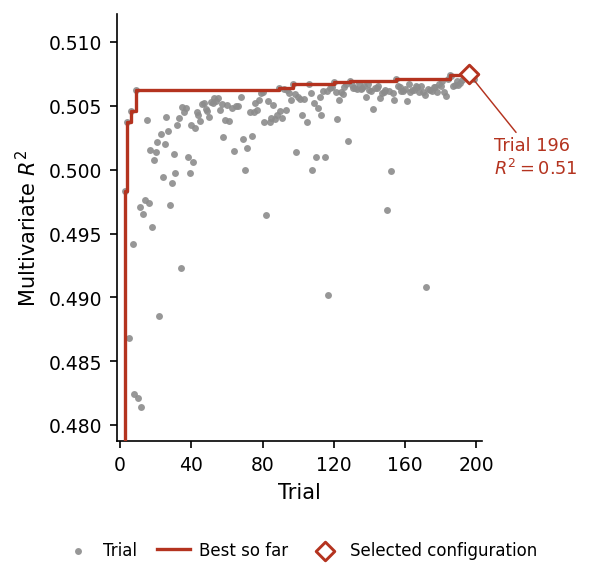

In [24]:
"""
Publication-style plots for an Optuna study, built directly with matplotlib
(no optuna.visualization, no ggplot styling).

Usage
-----
import optuna
study = optuna.load_study(study_name="mmer_xgb_parallel_folds",
                          storage=OPTUNA_STORAGE)

fig = plot_history(study, target_name=r"Multivariate $R^2$")
fig.savefig(FIGURES_DIR / "optuna_optimization_history.pdf", bbox_inches="tight")

fig = plot_params_over_trials(study, log_params=["learning_rate", "reg_alpha", "reg_lambda"])
fig.savefig(FIGURES_DIR / "optuna_params_over_trials.pdf", bbox_inches="tight")
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# --- a plain, journal-friendly base style -------------------------------
RC = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "legend.frameon": False,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 600,
}

ACCENT = "#B4331F"   # best-so-far line / best trial
DOTS = "#8C8C8C"     # individual trials


def _completed(study):
    """Return (trial_numbers, objective_values) for completed trials only."""
    nums, vals = [], []
    for t in study.trials:
        if t.value is not None and np.isfinite(t.value):
            nums.append(t.number)
            vals.append(t.value)
    order = np.argsort(nums)
    return np.asarray(nums)[order], np.asarray(vals)[order]


def plot_history(study, target_name=r"Multivariate $R^2$", figsize=(4.0, 4),
                 ylim=None, annotate=True):
    """Objective per trial + running best, in the style of a figure panel."""
    plt.style.use("default")  # reset standard Matplotlib appearance
    nums, vals = _completed(study)
    best = np.maximum.accumulate(vals)
    i_best = int(np.argmax(vals))

    with plt.rc_context(RC):
        fig, ax = plt.subplots(figsize=figsize)

        ax.scatter(nums, vals, s=11, color=DOTS, alpha=0.9,
                   linewidths=0, label="Trial", zorder=2)
        ax.step(nums, best, where="post", color=ACCENT, lw=1.6,
                label="Best so far", zorder=3)
        ax.scatter([nums[i_best]], [vals[i_best]], s=40, marker="D",
                   facecolor="white", edgecolor=ACCENT, linewidths=1.4,
                   zorder=4, label="Selected configuration")

        if annotate:
            ax.annotate(
                 f"Trial {nums[i_best]}\n" + r"$R^2 = " + f"{vals[i_best]:.2f}" + r"$",
                xy=(nums[i_best], vals[i_best]),
                xytext=(12, -30), textcoords="offset points",
                fontsize=8.5, color=ACCENT, ha="left", va="top",
                arrowprops=dict(arrowstyle="-", lw=0.7, color=ACCENT,
                                shrinkA=0, shrinkB=4),
            )

        ax.set_xlabel("Trial")
        ax.set_ylabel(target_name)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
        ax.margins(x=0.02)

        # clip the y-range so a few catastrophic trials don't flatten the curve
        if ylim is None:
            lo = np.percentile(vals, 2)
            hi = vals.max()
            pad = 0.08 * (hi - lo) if hi > lo else 0.05
            ylim = (lo - pad, hi + 2.2 * pad)
        ax.set_ylim(*ylim)

        ax.set_axisbelow(True)
        #ax.legend(loc="lower right", handletextpad=0.5, borderaxespad=0.2)
        ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.22),   # 0.5 = centered, negative y = below the axes
        ncol=3,                        # spread horizontally instead of stacking
        frameon=False,
        handletextpad=0.5,
        fontsize=8,
        columnspacing=1.2,
        borderaxespad=0.0,
        )
        fig.tight_layout()
    return fig

fig = plot_history(study, target_name=r"Multivariate $R^2$")
fig.savefig(FIGURES_DIR / "optuna_optimization_history.svg", bbox_inches="tight")

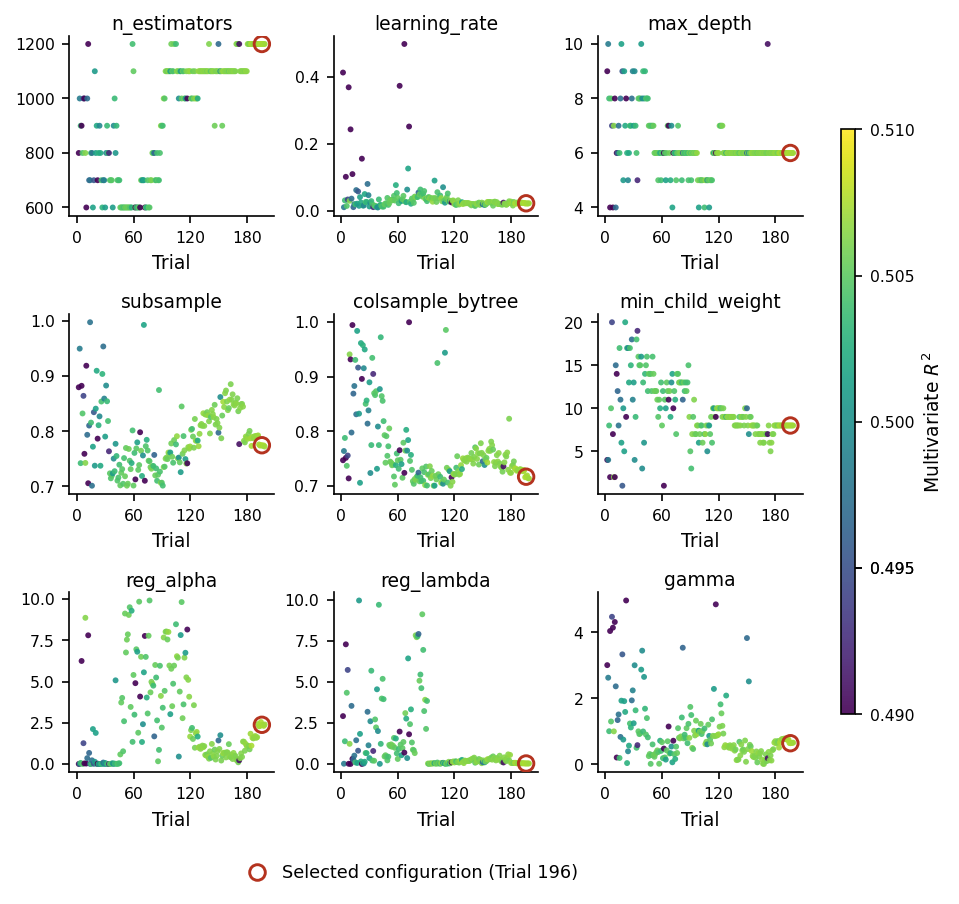

In [25]:
from matplotlib.colors import Normalize, LogNorm

from matplotlib.lines import Line2D


def plot_params_over_trials(study, params=None, log_params=(), ncols=3,
                            panel_size=(2.0, 2.0),
                            target_name=r"Multivariate $R^2$",
                            cmap="plasma",
                            cb_vmin=None,
                            cb_vmax=None,
                            cb_ticks=None,
                            cb_scale="linear"):
    """
    Parameters
    ----------
    cmap : str or Colormap
        Matplotlib colormap name, e.g. "viridis", "plasma", "coolwarm".
    cb_vmin, cb_vmax : float or None
        Explicit limits for the colorbar. If None, uses percentiles / max.
    cb_ticks : list or None
        Tick positions on the colorbar.
    cb_scale : {"linear", "log"}
        Scale of the colorbar (affects normalization).
    """
    nums, vals = _completed(study)
    plt.style.use("default")
    trials = {t.number: t for t in study.trials if t.value is not None}
    if params is None:
        params = list(study.best_params.keys())
    i_best = int(np.argmax(vals))
    best_num = nums[i_best]
    nrows = int(np.ceil(len(params) / ncols))
    with plt.rc_context(RC):
        fig, axes = plt.subplots(nrows, ncols, figsize=(panel_size[0] * ncols,
                                                        panel_size[1] * nrows))
        axes = np.atleast_1d(axes).ravel()
        # Default colorbar limits if not provided
        if cb_vmin is None:
            cb_vmin = np.percentile(vals, 5)
        if cb_vmax is None:
            cb_vmax = vals.max()
        # Choose normalization
        if cb_scale == "log":
            norm = LogNorm(vmin=cb_vmin, vmax=cb_vmax)
        else:
            norm = Normalize(vmin=cb_vmin, vmax=cb_vmax)
        for ax, p in zip(axes, params):
            x = [n for n in nums if p in trials[n].params]
            y = [trials[n].params[p] for n in x]
            c = [trials[n].value for n in x]
            sc = ax.scatter(x, y, c=c, cmap=cmap, norm=norm,
                            s=8, linewidths=0, alpha=0.9)
            if p in trials[best_num].params:
                ax.scatter([best_num], [trials[best_num].params[p]], s=55,
                           facecolor="none", edgecolor=ACCENT, linewidths=1.4,
                           zorder=5)
            if p in log_params:
                ax.set_yscale("log")
            ax.set_title(p, pad=3, fontsize=9)
            ax.set_xlabel("Trial", fontsize=9)
            ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=4))
            ax.tick_params(labelsize=7.5)
        for ax in axes[len(params):]:
            ax.set_visible(False)

        # legend explaining the open circles
        best_handle = Line2D(
            [0], [0], marker="o", linestyle="none",
            markerfacecolor="none", markeredgecolor=ACCENT,
            markeredgewidth=1.4, markersize=7.5,
            label=f"Selected configuration (Trial {best_num})",
        )
        fig.legend(handles=[best_handle], loc="lower center",
                   bbox_to_anchor=(0.46, 0.0), frameon=False,
                   fontsize=8.5, handletextpad=0.4, borderaxespad=0.3)

        bottom = 0.30 / (panel_size[1] * nrows)
        fig.tight_layout(rect=(0, bottom, 0.92, 1))
        cax = fig.add_axes((0.94, 0.15 + bottom, 0.016, 0.7 - bottom))
        cb = fig.colorbar(sc, cax=cax)
        cb.set_label(target_name, fontsize=9)
        cb.ax.tick_params(labelsize=7.5)
        # Custom colorbar ticks
        if cb_ticks is not None:
            cb.set_ticks(cb_ticks)
    return fig
    
fig = plot_params_over_trials(
    study,
    target_name=r"Multivariate $R^2$",
    cmap="viridis",
    cb_vmin=0.490,
    cb_vmax=0.51,
    cb_ticks=[0.49,0.495,0.495,0.50, 0.505, 0.51],  # custom ticks
    cb_scale="linear"         # or "log"
)
fig.savefig(FIGURES_DIR / "optuna_params_over_trials.svg", bbox_inches="tight")